# Importing Dependencies

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

make_block generator datas

# Loading Dataset and Preprocessing

In [69]:
X, Y = make_blobs(n_samples=500, centers=3, cluster_std=4, random_state=42) # Three clustures

Since we are not predicting anything we will not neeed Y

In [70]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [71]:
df

,Feature_1,Feature_2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868
...,...,...
495,-1.282205,-3.181575
496,-2.817604,10.378894
497,3.296740,8.649256
498,-8.970519,-2.684073


In [72]:
df.head()

,Feature_1,Feature_2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868


# StandardScalar

In [73]:
scalar = StandardScaler()


In [74]:
X_scaled = scalar.fit_transform(df)

In [75]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [76]:
kmeans.inertia_

119.94101297104991

In [77]:
K_range = range(1,11)

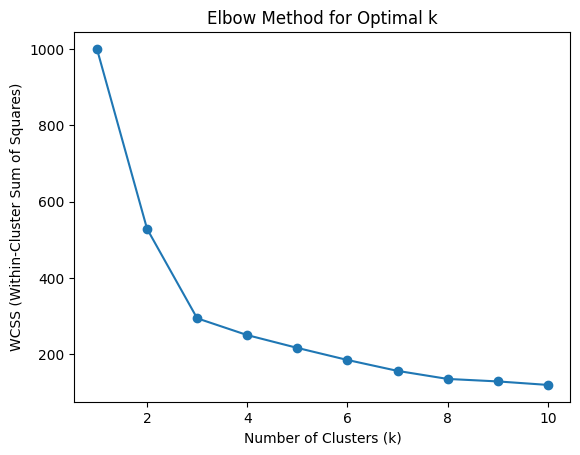

In [78]:
plt.plot(K_range, wcss, marker = 'o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.show()

We are choosing clusture as 3

In [79]:
kmeans_final = KMeans(n_clusters=3, init='k-means++')
cluster_label = kmeans_final.fit_predict(X_scaled)

In [80]:
cluster_label

array([2, 1, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 1, 2, 2, 1, 1, 1,
       0, 2, 2, 0, 0, 2, 2, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 2, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 2, 2, 1, 2, 2, 0, 1, 1, 2, 0, 2, 2, 1, 0, 2, 0, 2,
       0, 2, 1, 0, 0, 0, 0, 2, 1, 2, 0, 0, 1, 1, 2, 1, 0, 1, 2, 2, 2, 1,
       0, 1, 2, 0, 1, 0, 0, 2, 1, 1, 1, 2, 0, 1, 0, 2, 2, 1, 1, 2, 1, 2,
       2, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 0, 0, 0, 0, 1, 0, 2, 2, 2, 0,
       1, 2, 0, 2, 2, 2, 2, 1, 2, 2, 0, 0, 2, 2, 2, 1, 1, 1, 0, 2, 0, 1,
       1, 2, 1, 2, 0, 0, 0, 2, 1, 1, 2, 1, 1, 0, 2, 2, 2, 1, 1, 2, 2, 1,
       1, 1, 0, 0, 1, 2, 0, 1, 2, 2, 0, 0, 1, 2, 2, 2, 2, 2, 1, 0, 1, 1,
       2, 0, 1, 0, 2, 2, 0, 2, 2, 1, 1, 2, 2, 0, 2, 1, 1, 2, 1, 2, 1, 0,
       1, 1, 2, 1, 0, 1, 1, 2, 0, 0, 0, 0, 1, 2, 2, 2, 1, 0, 1, 0, 0, 2,
       1, 1, 2, 2, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 2, 1, 0, 1, 1, 1, 2, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 2, 1, 1, 1, 1, 2, 2, 0, 0, 1, 1, 2, 1,
       0, 2, 0, 0, 2, 1, 1, 1, 2, 1, 2, 1, 0, 0, 0,

In [81]:
df['clustur'] = cluster_label

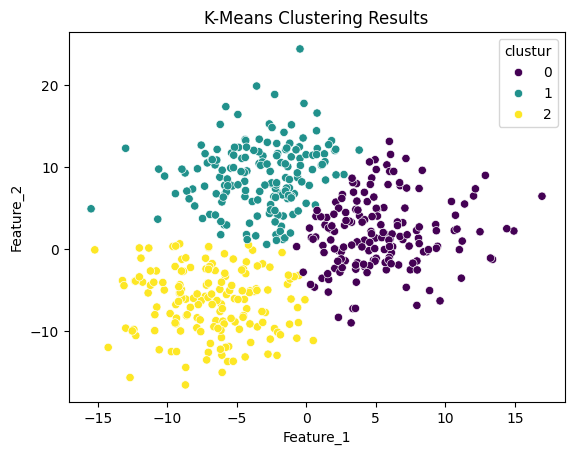

In [82]:
sns.scatterplot(data=df, x='Feature_1', y='Feature_2', hue='clustur', palette='viridis')
plt.title('K-Means Clustering Results')
plt.show()